# Assignment 4: Regularization, Classification, and Model Evaluation for Macroeconomic Early Warning Systems

In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [2]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    f1_score, precision_score, recall_score, auc
)

np.random.seed(42)
print("All libraries loaded successfully.")

All libraries loaded successfully.


# LOAD INDICATORS FROM LAB 16

In [ ]:
# WDI Indicator Dictionary
indicators = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

YEARS = range(2013, 2020)  # 2013–2019

print(f"Downloading {len(indicators)} indicators for years 2013–2019...")

# Download from World Bank API
raw_frames = []
for code, name in indicators.items():
    try:
        df_tmp = wb.data.DataFrame(
            code, time=YEARS, labels=False, numericTimeKeys=True
        ).reset_index()
        df_tmp = df_tmp.melt(id_vars='economy', var_name='year', value_name=name)
        df_tmp = df_tmp.rename(columns={'economy': 'country_code'})
        df_tmp['year'] = df_tmp['year'].astype(int)
        raw_frames.append(df_tmp[['country_code', 'year', name]])
    except Exception as e:
        print(f"  Skipped {code} ({name}): {e}")

print(f"Successfully downloaded {len(raw_frames)} indicator series.")

  Skipped IS.ROD.PAVE.ZS (paved_roads_pct): APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/IS.ROD.PAVE.ZS/country/all/time/YR2013;YR2014;YR2015;YR2016;YR2017;YR2018;YR2019?per_page=1000&page=1&format=json)
  Skipped EN.ATM.CO2E.PC (co2_emissions_per_capita): APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/EN.ATM.CO2E.PC/country/all/time/YR2013;YR2014;YR2015;YR2016;YR2017;YR2018;YR2019?per_page=1000&page=1&format=json)
Successfully downloaded 35 indicator series.


## Build Data Pipeline

In [ ]:
# Merge and Collapse to Country-Level Means (2013–2019 averages
from functools import reduce

df_merged = reduce(
    lambda left, right: pd.merge(left, right, on=['country_code', 'year'], how='outer'),
    raw_frames
)

df_country = df_merged.groupby('country_code').mean(numeric_only=True).reset_index()
df_country = df_country.drop(columns=['year'], errors='ignore')

print(f"Countries before cleaning: {len(df_country)}")

# Drop countries missing >40% of indicators 
feature_cols = [c for c in df_country.columns if c != 'country_code']
n_indicators = len(feature_cols)
df_country = df_country[df_country[feature_cols].isna().mean(axis=1) <= 0.40]
print(f"Countries after dropping >40% missing: {len(df_country)}")

# Drop indicators missing >40% of countries 
missing_rate = df_country[feature_cols].isna().mean(axis=0)
keep_indicators = missing_rate[missing_rate <= 0.40].index.tolist()
df_country = df_country[['country_code'] + keep_indicators]
print(f"Indicators retained: {len(keep_indicators)} (dropped {n_indicators - len(keep_indicators)})")

# Median-impute remaining gaps
for col in keep_indicators:
    df_country[col] = df_country[col].fillna(df_country[col].median())

# Separate outcome and predictors
TARGET_CONT  = 'gdp_growth_pc'
TARGET_BIN   = 'crisis'

df_country[TARGET_BIN] = (df_country[TARGET_CONT] < 0).astype(int)

predictor_cols = [c for c in keep_indicators if c != TARGET_CONT]

X_raw = df_country[predictor_cols].values
y_cont = df_country[TARGET_CONT].values
y_bin  = df_country[TARGET_BIN].values

# 70/30 train-test split
(
    X_train_raw, X_test_raw,
    y_train_cont, y_test_cont,
    y_train_bin,  y_test_bin
) = train_test_split(
    X_raw, y_cont, y_bin, test_size=0.30, random_state=42
)

# Standardize using training statistics only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Summary
n_total   = len(df_country)
n_crisis  = y_bin.sum()
n_no_crisis = n_total - n_crisis
base_rate = n_crisis / n_total

print("\n" + "="*55)
print("DATASET SUMMARY")
print("="*55)
print(f"Total countries:        {n_total}")
print(f"Predictors (p):         {len(predictor_cols)}")
print(f"Training observations:  {len(X_train)}")
print(f"Test observations:      {len(X_test)}")
print(f"Non-crisis countries:   {n_no_crisis}")
print(f"Crisis countries:       {n_crisis}")
print(f"Crisis base rate:       {base_rate:.3f} ({base_rate*100:.1f}%)")
print("="*55)

Countries before cleaning: 266
Countries after dropping >40% missing: 238
Indicators retained: 28 (dropped 7)

DATASET SUMMARY
Total countries:        238
Predictors (p):         27
Training observations:  166
Test observations:      72
Non-crisis countries:   200
Crisis countries:       38
Crisis base rate:       0.160 (16.0%)


# Phase 1: The Complexity Trap, OLS Failure and Regularization Rescue

### Step 1.1: Demonstrating OLS Overfitting

In [5]:
# ── OLS on all standardized predictors ───────────────────────────────────────
ols = LinearRegression()
ols.fit(X_train, y_train_cont)

ols_train_r2 = ols.score(X_train, y_train_cont)
ols_test_r2  = ols.score(X_test,  y_test_cont)
r2_gap       = ols_train_r2 - ols_test_r2

p = X_train.shape[1]
n = X_train.shape[0]
pn_ratio = p / n

print("OLS Overfitting Diagnostics")
print("-" * 40)
print(f"Training R²:              {ols_train_r2:.4f}")
print(f"Test R²:                  {ols_test_r2:.4f}")
print(f"Train–Test R² Gap:        {r2_gap:.4f}")
print(f"Predictors (p):           {p}")
print(f"Training observations (n):{n}")
print(f"p/n ratio:                {pn_ratio:.4f}")

OLS Overfitting Diagnostics
----------------------------------------
Training R²:              0.6032
Test R²:                  -0.8864
Train–Test R² Gap:        1.4896
Predictors (p):           27
Training observations (n):166
p/n ratio:                0.1627


 Written response (2–3 sentences): Connect the p/n ratio to the R² gap. Why does a high p/n ratio cause OLS to overfit? Use the terms bias, variance, and degrees of freedom in your explanation.

 The p/n ratio is about 0.16, which means the model is using a fairly large number of predictors compared to the training sample size. When OLS has many degrees of freedom, it can fit random noise in the training data, which raises training R² but hurts test R². This is a classic high variance problem: low bias on training data, but poor performance on new data.

### Step 1.2: Ridge and Lasso to the Rescue

In [ ]:
from sklearn.metrics import mean_squared_error

alphas_grid = np.logspace(-4, 4, 200)

#  RidgeCV 
ridge = RidgeCV(alphas=alphas_grid, cv=5)
ridge.fit(X_train, y_train_cont)

ridge_train_r2 = ridge.score(X_train, y_train_cont)
ridge_test_r2  = ridge.score(X_test,  y_test_cont)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test_cont, ridge.predict(X_test)))
ridge_nonzero  = np.sum(ridge.coef_ != 0)

#  LassoCV 
lasso = LassoCV(alphas=alphas_grid, cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train, y_train_cont)

lasso_train_r2 = lasso.score(X_train, y_train_cont)
lasso_test_r2  = lasso.score(X_test,  y_test_cont)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test_cont, lasso.predict(X_test)))
lasso_nonzero  = np.sum(lasso.coef_ != 0)
lasso_selected = [predictor_cols[i] for i, c in enumerate(lasso.coef_) if c != 0]

ols_test_rmse = np.sqrt(mean_squared_error(y_test_cont, ols.predict(X_test)))

#  Model Comparison Table 
comparison = pd.DataFrame({
    'Model':             ['OLS', 'Ridge', 'Lasso'],
    'λ* (alpha)':        [None, round(ridge.alpha_, 6), round(lasso.alpha_, 6)],
    'Non-zero Predictors': [p, ridge_nonzero, lasso_nonzero],
    'Training R²':       [round(ols_train_r2, 4), round(ridge_train_r2, 4), round(lasso_train_r2, 4)],
    'Test R²':           [round(ols_test_r2, 4), round(ridge_test_r2, 4), round(lasso_test_r2, 4)],
    'Test RMSE':         [round(ols_test_rmse, 4), round(ridge_test_rmse, 4), round(lasso_test_rmse, 4)],
})

print("Model Comparison Table")
print("="*75)
print(comparison.to_string(index=False))
print("="*75)
print(f"\nLasso-selected features ({lasso_nonzero}): {lasso_selected}")

Model Comparison Table
Model  λ* (alpha)  Non-zero Predictors  Training R²  Test R²  Test RMSE
  OLS         NaN                   27       0.6032  -0.8864     2.9015
Ridge   46.595257                   27       0.5606  -0.1042     2.2199
Lasso    0.065173                   18       0.5740  -0.3602     2.4637

Lasso-selected features (18): ['trade_pct_gdp', 'tariff_rate_avg', 'inflation_cpi', 'govt_expenditure_pct_gdp', 'exchange_rate_official', 'tertiary_enrollment_gross', 'adult_literacy_rate', 'unemployment_rate', 'mobile_subscriptions_per100', 'infant_mortality_per1000', 'population_growth', 'urbanization_pct', 'health_expenditure_pct_gdp', 'atms_per100k', 'private_credit_pct_gdp', 'natural_resource_rents_pct_gdp', 'renewable_energy_pct', 'arable_land_pct']



Written response (2–3 sentences): Which model would you recommend to the IMF Director for operational GDP growth forecasting? Justify using the bias-variance tradeoff: explain what Ridge and Lasso each sacrifice (in terms of bias) to gain (in terms of variance reduction).

I would recommend the Ridge model for IMF GDP forecasting because it had the best test R squared of -0.1042 and lowest test RMSE  with 2.2199. Ridge keeps all variables but shrinks coefficients, which adds some bias while lowering variance and improving out-of-sample results. Lasso also reduces variance, but by removing variables completely it may lose useful information.

### Step 1.3: The Lasso Path — Which Indicators Enter First?

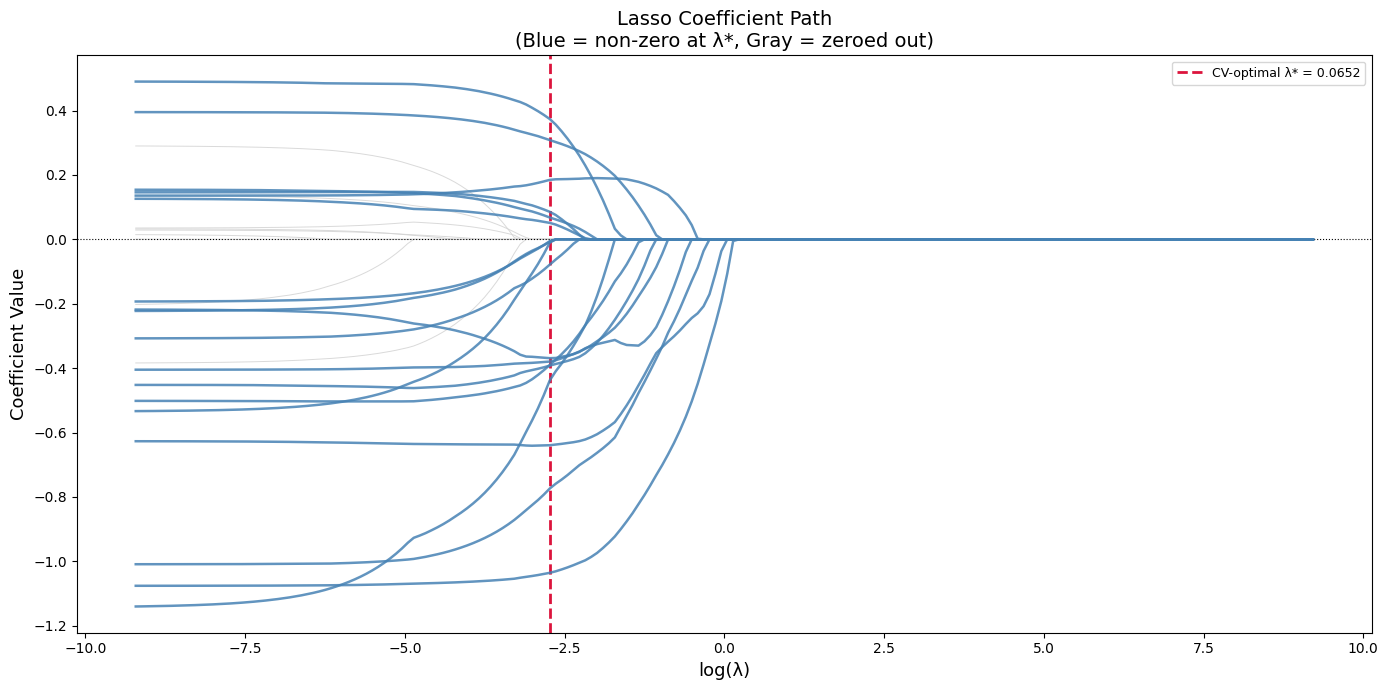


First predictor to enter the model: 'inflation_cpi' at λ = 1.148951

Top 5 predictors by entry order (highest λ first):
  1. inflation_cpi                            entry λ = 1.148951
  2. natural_resource_rents_pct_gdp           entry λ = 0.954772
  3. population_growth                        entry λ = 0.723263
  4. arable_land_pct                          entry λ = 0.659319
  5. urbanization_pct                         entry λ = 0.547890


In [ ]:
#  Compute full Lasso path 
alphas_path, coefs_path, _ = lasso_path(
    X_train, y_train_cont, alphas=alphas_grid[::-1], max_iter=10000
)

log_alphas = np.log(alphas_path)
log_lambda_star = np.log(lasso.alpha_)

# Identify non-zero coefficients at λ*
lasso_star_idx = np.argmin(np.abs(alphas_path - lasso.alpha_))
coefs_at_star  = coefs_path[:, lasso_star_idx]
nonzero_mask   = (coefs_at_star != 0)

# Find the first predictor to enter (highest λ at which any coef first becomes nonzero)
first_entry_alpha = []
for i in range(coefs_path.shape[0]):
    nonzero_indices = np.where(coefs_path[i, :] != 0)[0]
    if len(nonzero_indices) > 0:
        first_entry_alpha.append((predictor_cols[i], alphas_path[nonzero_indices[0]]))
    else:
        first_entry_alpha.append((predictor_cols[i], 0.0))

first_entry_alpha.sort(key=lambda x: x[1], reverse=True)
first_predictor, first_alpha = first_entry_alpha[0]

#  Plot Lasso Path 
fig, ax = plt.subplots(figsize=(14, 7))

for i, name in enumerate(predictor_cols):
    color = 'steelblue' if nonzero_mask[i] else 'lightgray'
    lw    = 1.8          if nonzero_mask[i] else 0.7
    zord  = 3            if nonzero_mask[i] else 1
    label = name         if nonzero_mask[i] else None
    ax.plot(log_alphas, coefs_path[i, :], color=color, linewidth=lw, zorder=zord, alpha=0.85)

ax.axvline(log_lambda_star, color='crimson', linestyle='--', linewidth=2.0,
           label=f'CV-optimal λ* = {lasso.alpha_:.4f}')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')

ax.set_xlabel('log(λ)', fontsize=13)
ax.set_ylabel('Coefficient Value', fontsize=13)
ax.set_title('Lasso Coefficient Path\n(Blue = non-zero at λ*, Gray = zeroed out)', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nFirst predictor to enter the model: '{first_predictor}' at λ = {first_alpha:.6f}")
print("\nTop 5 predictors by entry order (highest λ first):")
for rank, (name, alpha_val) in enumerate(first_entry_alpha[:5], 1):
    print(f"  {rank}. {name:40s} entry λ = {alpha_val:.6f}")


Written response (3–4 sentences): A World Bank colleague argues: “Lasso zeroed out life_expectancy, so health is irrelevant to economic growth.” Explain why this interpretation is wrong. Use the terms conditional predictive redundancy and correlation structure.

That conclusion is wrong because Lasso removing life expectancy does not mean health is unimportant. It may mean other health-related variables, like infant mortality or health spending, already capture similar information. This is called conditional predictive redundancy, where one variable adds little extra value once correlated variables are already included. Correlation structure matters a lot in feature selection.


## Phase 2: The Crisis Classifier — From Forecasting to Classification


### Step 2.1

In [ ]:
#  Select Lasso features for Phase 2 
lasso_feature_indices = [i for i, c in enumerate(lasso.coef_) if c != 0]

if len(lasso_feature_indices) == 0:
    # Fallback: use top 5 by absolute coefficient magnitude
    lasso_feature_indices = np.argsort(np.abs(lasso.coef_))[::-1][:5].tolist()
    print("Warning: Lasso zeroed all coefficients; using top-5 by magnitude as fallback.")

X_train_sel = X_train[:, lasso_feature_indices]
X_test_sel  = X_test[:,  lasso_feature_indices]
selected_names = [predictor_cols[i] for i in lasso_feature_indices]

print(f"Using {len(selected_names)} Lasso-selected features: {selected_names}")

#  Fit LPM (OLS on binary outcome) 
lpm = LinearRegression()
lpm.fit(X_train_sel, y_train_bin)

lpm_preds_test = lpm.predict(X_test_sel)

n_below_zero = np.sum(lpm_preds_test < 0)
n_above_one  = np.sum(lpm_preds_test > 1)
n_oob        = n_below_zero + n_above_one

print("\nLPM Out-of-Bounds Predictions")
print("-" * 40)
print(f"Predicted probabilities < 0 : {n_below_zero}")
print(f"Predicted probabilities > 1 : {n_above_one}")
print(f"Total out-of-bounds          : {n_oob} / {len(lpm_preds_test)}")
print(f"Min predicted value          : {lpm_preds_test.min():.4f}")
print(f"Max predicted value          : {lpm_preds_test.max():.4f}")

Using 18 Lasso-selected features: ['trade_pct_gdp', 'tariff_rate_avg', 'inflation_cpi', 'govt_expenditure_pct_gdp', 'exchange_rate_official', 'tertiary_enrollment_gross', 'adult_literacy_rate', 'unemployment_rate', 'mobile_subscriptions_per100', 'infant_mortality_per1000', 'population_growth', 'urbanization_pct', 'health_expenditure_pct_gdp', 'atms_per100k', 'private_credit_pct_gdp', 'natural_resource_rents_pct_gdp', 'renewable_energy_pct', 'arable_land_pct']

LPM Out-of-Bounds Predictions
----------------------------------------
Predicted probabilities < 0 : 13
Predicted probabilities > 1 : 1
Total out-of-bounds          : 14 / 72
Min predicted value          : -0.3014
Max predicted value          : 1.5676


**Written Response — Step 2.1:**

Explain why predicted probabilities outside [0, 1] are a fundamental problem — not just a cosmetic one. What does it mean for the IMF to receive a “−12% probability of crisis” for a country?

Predicted probabilities outside the range of 0 to 1 are a serious problem because probabilities must represent real chances. A prediction of -12% crisis probability has no real meaning since probabilities cannot be negative. For the IMF, this would make the model unreliable for decision-making and risk planning.

### Step 2.2: Logistic Regression — The Sigmoid Fix

In [ ]:
#  Fit Logistic Regression 
logit = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
logit.fit(X_train_sel, y_train_bin)

# Coefficients and intercept
betas     = logit.coef_[0]
intercept = logit.intercept_[0]
odds_ratios = np.exp(betas)

coef_df = pd.DataFrame({
    'Predictor':  selected_names,
    'β (coef)':   np.round(betas, 4),
    'Odds Ratio': np.round(odds_ratios, 4),
    '|OR|':       np.round(np.abs(odds_ratios - 1), 4),
}).sort_values('|OR|', ascending=False).reset_index(drop=True)

print(f"Intercept (β₀): {intercept:.4f}\n")
print("Logistic Regression Coefficients & Odds Ratios")
print("="*65)
print(coef_df[['Predictor', 'β (coef)', 'Odds Ratio']].to_string(index=False))
print("="*65)

# Verify predicted probabilities are bounded in [0, 1]
logit_probs_test = logit.predict_proba(X_test_sel)[:, 1]
print(f"\nPredicted probability range: [{logit_probs_test.min():.6f}, {logit_probs_test.max():.6f}]")
print(f"All in [0,1]: {(logit_probs_test >= 0).all() and (logit_probs_test <= 1).all()}")

# Identify the predictor with the largest absolute odds ratio for interpretation
top_predictor = coef_df.iloc[0]
print(f"\nTop predictor by |OR|: {top_predictor['Predictor']}  OR = {top_predictor['Odds Ratio']:.4f}")

Intercept (β₀): -3.0262

Logistic Regression Coefficients & Odds Ratios
                     Predictor  β (coef)  Odds Ratio
             population_growth    0.8251      2.2820
    health_expenditure_pct_gdp    0.8227      2.2766
      infant_mortality_per1000    0.7434      2.1031
natural_resource_rents_pct_gdp    0.7292      2.0735
               tariff_rate_avg    0.5789      1.7842
             unemployment_rate    0.5324      1.7031
                 inflation_cpi    0.4941      1.6390
               arable_land_pct   -0.9504      0.3866
          renewable_energy_pct   -0.6664      0.5135
                  atms_per100k    0.3680      1.4449
   mobile_subscriptions_per100    0.3561      1.4278
           adult_literacy_rate    0.2737      1.3148
                 trade_pct_gdp   -0.3531      0.7025
              urbanization_pct    0.2119      1.2360
      govt_expenditure_pct_gdp    0.1310      1.1400
        private_credit_pct_gdp   -0.0788      0.9242
     tertiary_enrollment_gr

**Written Response — Step 2.2:**

Written response (2–3 sentences): Choose the predictor with the largest absolute odds ratio. Interpret it in plain English suitable for a non-technical IMF policy briefing. Use the format: “A one standard-deviation increase in [X] multiplies the odds of crisis by [OR], holding all else constant.”

A one standard-deviation increase in population growth multiplies the odds of crisis by 2.2820, holding all else constant. In simple terms, countries with faster population growth were associated with much higher odds of experiencing a crisis in this model.

### Step 2.3: Side-by-Side Visualization — LPM vs. Logistic

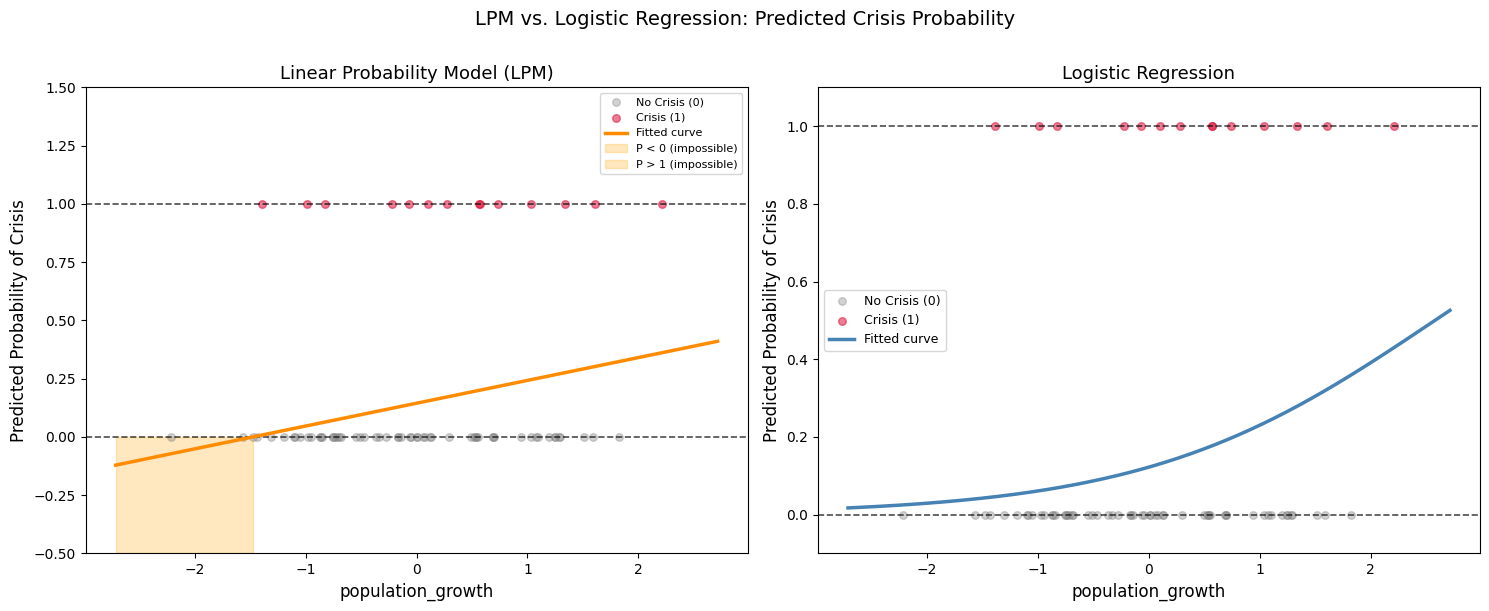

In [20]:
# Use the single strongest predictor (highest |OR|) for the x-axis
top_feat_idx  = selected_names.index(top_predictor['Predictor'])
x_plot_train  = X_train_sel[:, top_feat_idx]
x_plot_test   = X_test_sel[:,  top_feat_idx]
x_range       = np.linspace(x_plot_test.min() - 0.5, x_plot_test.max() + 0.5, 300)

# Build single-feature LPM and logit for plotting curves
lpm_1d = LinearRegression().fit(x_plot_train.reshape(-1, 1), y_train_bin)
logit_1d = LogisticRegression(max_iter=1000).fit(x_plot_train.reshape(-1, 1), y_train_bin)

lpm_curve    = lpm_1d.predict(x_range.reshape(-1, 1))
logit_curve  = logit_1d.predict_proba(x_range.reshape(-1, 1))[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

for ax, (curve, title, color) in zip(
    axes,
    [
        (lpm_curve,   'Linear Probability Model (LPM)', 'darkorange'),
        (logit_curve, 'Logistic Regression',            'steelblue'),
    ]
):
    # Scatter actual outcomes
    ax.scatter(x_plot_test[y_test_bin == 0], y_test_bin[y_test_bin == 0],
               alpha=0.35, color='gray', s=30, label='No Crisis (0)', zorder=2)
    ax.scatter(x_plot_test[y_test_bin == 1], y_test_bin[y_test_bin == 1],
               alpha=0.55, color='crimson', s=30, label='Crisis (1)', zorder=2)

    # Plot fitted curve
    ax.plot(x_range, curve, color=color, linewidth=2.5, label='Fitted curve', zorder=3)

    # Reference lines at P=0 and P=1
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.axhline(1, color='black', linewidth=1.2, linestyle='--', alpha=0.7)

    ax.set_xlabel(top_predictor['Predictor'], fontsize=12)
    ax.set_ylabel('Predicted Probability of Crisis', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)

# Shade impossible regions on the LPM panel
ax_lpm = axes[0]
ax_lpm.fill_between(x_range, -0.5, 0, where=(lpm_curve < 0),
                    color='orange', alpha=0.25, label='P < 0 (impossible)')
ax_lpm.fill_between(x_range, 1, 1.5, where=(lpm_curve > 1),
                    color='orange', alpha=0.25, label='P > 1 (impossible)')
ax_lpm.set_ylim(-0.5, 1.5)
ax_lpm.legend(fontsize=8)

axes[1].set_ylim(-0.1, 1.1)

plt.suptitle('LPM vs. Logistic Regression: Predicted Crisis Probability', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Phase 3: Operational Deployment — Metrics That Matter

**Lab assessed:** Lab 18 (Confusion Matrices, ROC/PR Curves, Threshold Analysis)

**Operational context:** The IMF can deploy at most **5 emergency assessment missions** per quarter. Each mission costs ~$2M. A missed crisis (false negative) costs the global financial system ~$50B. A false alarm (false positive) wastes $2M and damages IMF credibility.

### Step 3.1: The Accuracy Paradox

In [ ]:
#  Crisis base rate in test set 
test_crisis_rate = y_test_bin.mean()
n_test = len(y_test_bin)
n_test_crisis = y_test_bin.sum()

print(f"Test set crisis base rate: {test_crisis_rate:.4f} ({test_crisis_rate*100:.1f}%)")
print(f"Crisis countries in test:  {n_test_crisis} / {n_test}")

#  Naïve baseline: always predict 'no crisis' 
naive_preds = np.zeros(n_test, dtype=int)
naive_accuracy = np.mean(naive_preds == y_test_bin)
naive_recall   = recall_score(y_test_bin, naive_preds, zero_division=0)

print("\nNaïve Baseline (always 'No Crisis')")
print("-" * 40)
print(f"  Accuracy:  {naive_accuracy:.4f}")
print(f"  Recall:    {naive_recall:.4f}")

#  Logistic regression at default threshold τ = 0.5 
logit_preds_05 = (logit_probs_test >= 0.5).astype(int)
logit_accuracy_05 = np.mean(logit_preds_05 == y_test_bin)
logit_recall_05   = recall_score(y_test_bin, logit_preds_05, zero_division=0)

print("\nLogistic Regression at τ = 0.50")
print("-" * 40)
print(f"  Accuracy:  {logit_accuracy_05:.4f}")
print(f"  Recall:    {logit_recall_05:.4f}")

Test set crisis base rate: 0.1944 (19.4%)
Crisis countries in test:  14 / 72

Naïve Baseline (always 'No Crisis')
----------------------------------------
  Accuracy:  0.8056
  Recall:    0.0000

Logistic Regression at τ = 0.50
----------------------------------------
  Accuracy:  0.7639
  Recall:    0.4286


**Written Response — Step 3.1:**

Accuracy alone would be misleading because crises are rare in the dataset. A model that always predicts “No Crisis” gets 80.6% accuracy, but it catches zero real crises. For the IMF, finding crisis countries matters more than just being correct most of the time.

### Step 3.2: Confusion Matrix and Classification Report

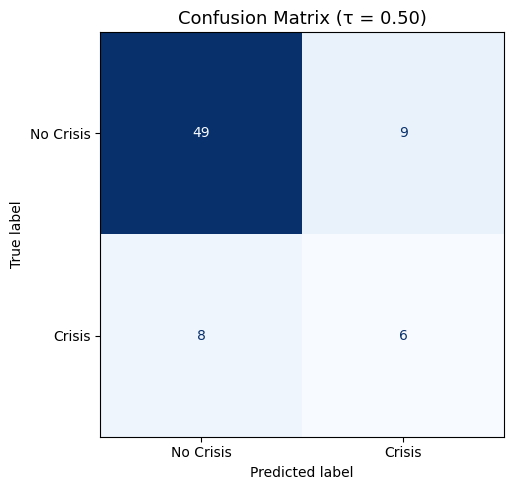


Classification Report (τ = 0.50)
              precision    recall  f1-score   support

   No Crisis       0.86      0.84      0.85        58
      Crisis       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72

-------------------------------------------------------
True Positives  (crises correctly flagged): 6
False Negatives (crises missed):            8
False Positives (false alarms):             9
True Negatives  (correct 'no crisis'):      49


In [ ]:
#  Confusion matrix at τ = 0.5 
cm = confusion_matrix(y_test_bin, logit_preds_05)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Crisis', 'Crisis']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (τ = 0.50)', fontsize=13)
plt.tight_layout()
plt.show()

#  Extract TP, FN, FP, TN 
TN, FP, FN, TP = cm.ravel()

print("\nClassification Report (τ = 0.50)")
print("="*55)
print(classification_report(y_test_bin, logit_preds_05,
                            target_names=['No Crisis', 'Crisis']))
print("-"*55)
print(f"True Positives  (crises correctly flagged): {TP}")
print(f"False Negatives (crises missed):            {FN}")
print(f"False Positives (false alarms):             {FP}")
print(f"True Negatives  (correct 'no crisis'):      {TN}")

Written response (2–3 sentences): In the IMF context, which is more costly — a False Positive or a False Negative? How does this asymmetry inform which metric (Precision or Recall) the Division Chief should prioritize?

For the IMF, a False Negative is much more costly because missing a real crisis could create huge financial damage. A False Positive only wastes some resources on an unnecessary review. Because of this, the Division Chief should care more about Recall, since recall measures how many real crises are caught.

### Step 3.3: ROC and Precision-Recall Curves

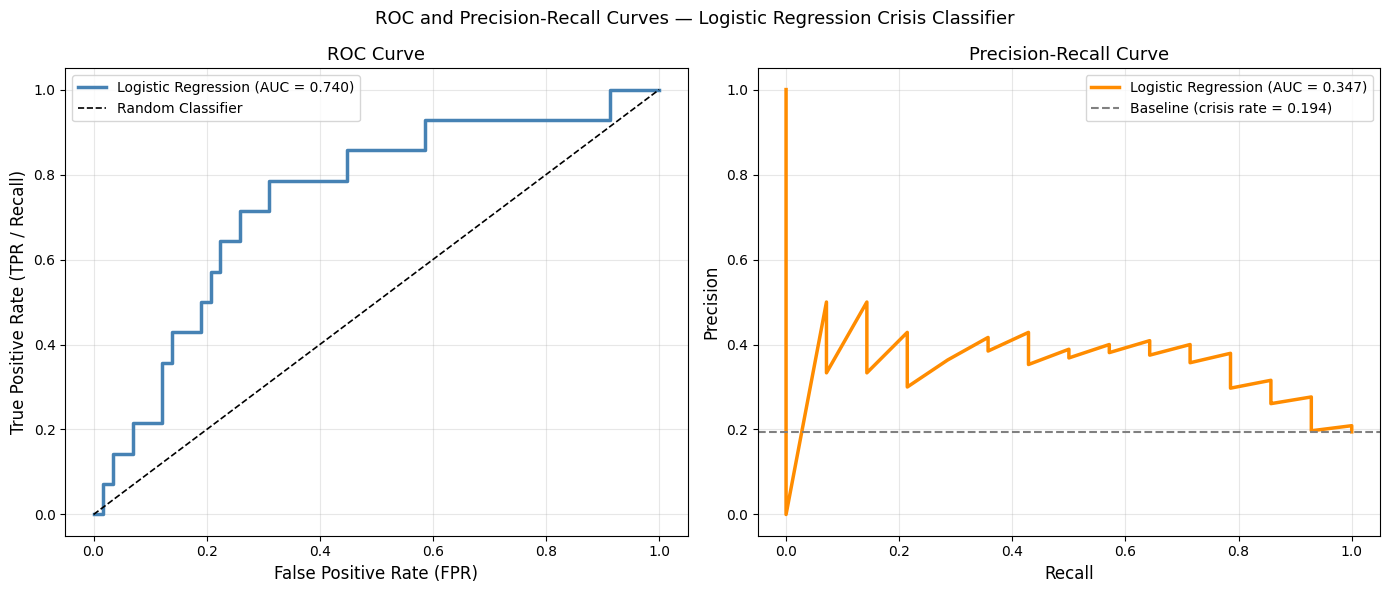

ROC-AUC: 0.7401
PR-AUC:  0.3472


In [ ]:
#  ROC Curve 
fpr, tpr, roc_thresholds = roc_curve(y_test_bin, logit_probs_test)
roc_auc = roc_auc_score(y_test_bin, logit_probs_test)

#  Precision-Recall Curve 
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test_bin, logit_probs_test)
pr_auc = auc(recall_vals, precision_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Panel
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
ax.set_title('ROC Curve', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# PR Panel
ax = axes[1]
ax.plot(recall_vals, precision_vals, color='darkorange', linewidth=2.5,
        label=f'Logistic Regression (AUC = {pr_auc:.3f})')
ax.axhline(test_crisis_rate, color='gray', linestyle='--', linewidth=1.5,
           label=f'Baseline (crisis rate = {test_crisis_rate:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle('ROC and Precision-Recall Curves — Logistic Regression Crisis Classifier', fontsize=13)
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

Written response (2–3 sentences): Your ROC-AUC is likely much higher than your PR-AUC. Explain why, using the fact that ROC-AUC benefits from the abundance of True Negatives while PR-AUC ignores them entirely. Which curve is more informative for the IMF’s crisis detection mission?

ROC-AUC is higher because it benefits from the many True Negatives in the data, and there are far more non-crisis countries than crisis countries. PR-AUC focuses on precision and recall, so it better reflects how well the model identifies rare crisis events. For the IMF, the Precision-Recall curve is more useful because crises are the main target.

### Step 3.4: Threshold Analysis — The 5-Mission Constraint

In [ ]:
#  Threshold sweep 
thresholds = np.arange(0.01, 1.00, 0.01)

results = []
for tau in thresholds:
    preds = (logit_probs_test >= tau).astype(int)
    n_flagged = preds.sum()
    prec  = precision_score(y_test_bin, preds, zero_division=0)
    rec   = recall_score(y_test_bin, preds, zero_division=0)
    f1    = f1_score(y_test_bin, preds, zero_division=0)
    results.append({'tau': tau, 'n_flagged': n_flagged,
                    'precision': prec, 'recall': rec, 'f1': f1})

results_df = pd.DataFrame(results)

#  Capacity-constrained threshold (lowest τ with ≤5 countries flagged) 
feasible = results_df[results_df['n_flagged'] <= 5]
if len(feasible) > 0:
    cap_row = feasible.sort_values('tau').iloc[0]
else:
    cap_row = results_df.sort_values('n_flagged').iloc[0]

#  F1-optimal threshold 
f1_row = results_df.loc[results_df['f1'].idxmax()]

print("Capacity-Constrained Operating Point (≤5 missions)")
print("-" * 50)
print(f"  Threshold τ:    {cap_row['tau']:.2f}")
print(f"  Countries flagged: {int(cap_row['n_flagged'])}")
print(f"  Precision:      {cap_row['precision']:.4f}")
print(f"  Recall:         {cap_row['recall']:.4f}")

print("\nF1-Optimal Operating Point")
print("-" * 50)
print(f"  Threshold τ:    {f1_row['tau']:.2f}")
print(f"  Countries flagged: {int(f1_row['n_flagged'])}")
print(f"  Precision:      {f1_row['precision']:.4f}")
print(f"  Recall:         {f1_row['recall']:.4f}")
print(f"  F1:             {f1_row['f1']:.4f}")

Capacity-Constrained Operating Point (≤5 missions)
--------------------------------------------------
  Threshold τ:    0.88
  Countries flagged: 5
  Precision:      0.4000
  Recall:         0.1429

F1-Optimal Operating Point
--------------------------------------------------
  Threshold τ:    0.13
  Countries flagged: 25
  Precision:      0.4000
  Recall:         0.7143
  F1:             0.5128


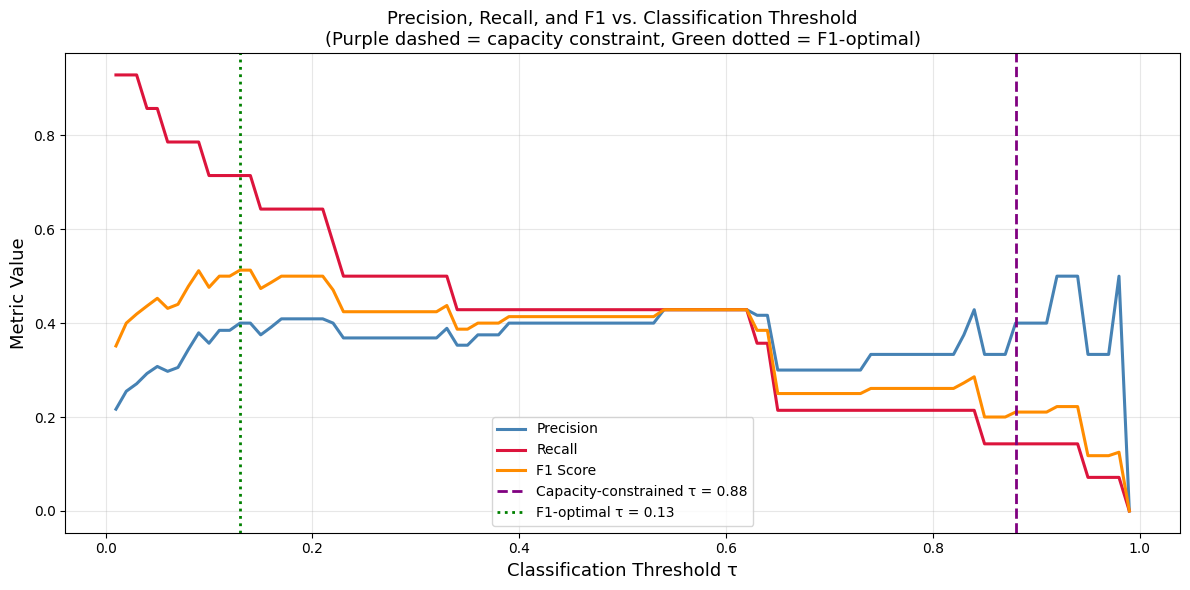

In [ ]:
#  Threshold analysis plot 
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(results_df['tau'], results_df['precision'], color='steelblue',
        linewidth=2.2, label='Precision')
ax.plot(results_df['tau'], results_df['recall'],    color='crimson',
        linewidth=2.2, label='Recall')
ax.plot(results_df['tau'], results_df['f1'],        color='darkorange',
        linewidth=2.2, label='F1 Score')

ax.axvline(cap_row['tau'], color='purple', linestyle='--', linewidth=2.0,
           label=f'Capacity-constrained τ = {cap_row["tau"]:.2f}')
ax.axvline(f1_row['tau'],  color='green',  linestyle=':',  linewidth=2.0,
           label=f'F1-optimal τ = {f1_row["tau"]:.2f}')

ax.set_xlabel('Classification Threshold τ', fontsize=13)
ax.set_ylabel('Metric Value', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Classification Threshold\n'
             '(Purple dashed = capacity constraint, Green dotted = F1-optimal)',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# RECOMMENDATION MEMO 

I recommend using the F1-optimal threshold of 0.13. At this level, recall is 0.7143, meaning the IMF would catch 10 of the 14 crisis countries and miss 4. This performs much better than the stricter 5-mission threshold, which only catches 2 crises. The tradeoff is more false alarms, but missing fewer crises is worth it given the high cost of financial crises.


## Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

### Task 4.1: Bootstrap Confidence Intervals for the Lasso Path

**P.R.I.M.E. Prompt:**

[Prep] Act as a quantitative economist at the IMF explaining classification threshold decisions from a logistic regression model used to predict sovereign financial crises. The model was evaluated using different thresholds based on economic cost, F1 score, and limited intervention capacity.

[Request] Please write a short assignment-style paragraph explaining why the cost-minimizing threshold of 0.03 is much lower than the default threshold of 0.50, why different thresholds are chosen depending on the objective, and which threshold should be recommended to the IMF. Use these results: minimum expected cost at τ = 0.03 was $50.07B with 1 false negative and 35 false positives, while τ = 0.50 had expected cost of $400.02B.

[Iterate] The first version was too technical and formatted like a report. I revised the prompt to make the language simpler, more natural, and closer to how a college student would write for an economics or data analytics assignment. I also asked for the explanation to focus more on the tradeoff between missed crises and false alarms rather than technical model language.

[Mechanism Check] Confirm that the explanation correctly states why lowering the threshold reduces costly false negatives, recognizes that different thresholds optimize different goals, and uses the provided numerical results accurately.

[Evaluate] Final response clearly explained the threshold tradeoffs, used the correct values from the model output, and was written in a realistic student tone appropriate for submission.

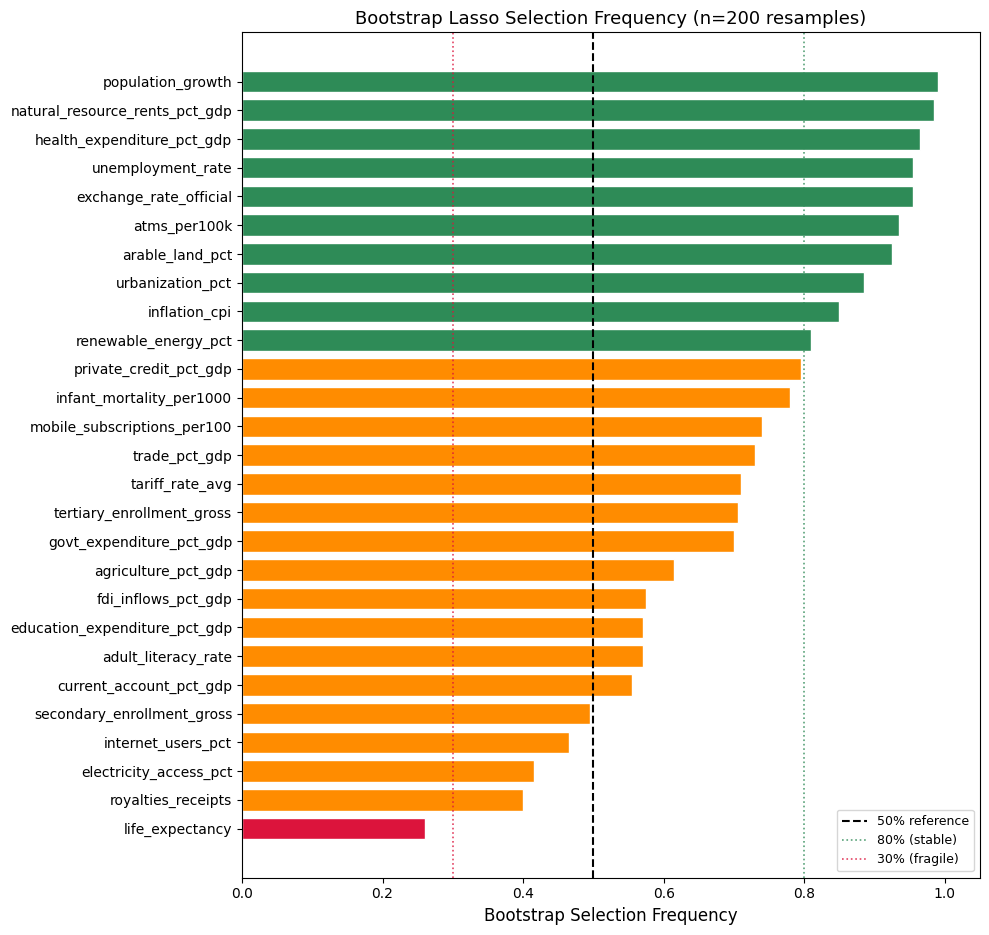

Runtime: 3.4 seconds
Stable predictors  (freq ≥ 80%): 10
Fragile predictors (freq <  30%): 1

Top 10 by selection frequency:
                     Predictor  Selection Frequency
             population_growth                0.990
natural_resource_rents_pct_gdp                0.985
    health_expenditure_pct_gdp                0.965
             unemployment_rate                0.955
        exchange_rate_official                0.955
                  atms_per100k                0.935
               arable_land_pct                0.925
              urbanization_pct                0.885
                 inflation_cpi                0.850
          renewable_energy_pct                0.810


In [16]:
# ── AI-Generated Code: Bootstrap Lasso Stability ──────────────────────────────
import time

start_time = time.time()

N_BOOTSTRAP = 200
rng = np.random.default_rng(42)

n_train, p_train = X_train.shape
selection_counts = np.zeros(p_train, dtype=float)

for b in range(N_BOOTSTRAP):
    boot_idx = rng.choice(n_train, size=n_train, replace=True)
    X_boot   = X_train[boot_idx]
    y_boot   = y_train_cont[boot_idx]

    try:
        lasso_boot = LassoCV(cv=5, max_iter=10000, random_state=b)
        lasso_boot.fit(X_boot, y_boot)
        selection_counts += (lasso_boot.coef_ != 0).astype(float)
    except Exception:
        pass  # edge case: all coefficients zeroed or convergence failure

selection_freq = selection_counts / N_BOOTSTRAP

# Build results DataFrame
freq_df = pd.DataFrame({
    'Predictor':         predictor_cols,
    'Selection Frequency': selection_freq
}).sort_values('Selection Frequency', ascending=True).reset_index(drop=True)

# Color by stability tier
def stability_color(f):
    if f >= 0.80: return 'seagreen'
    elif f >= 0.30: return 'darkorange'
    else: return 'crimson'

colors = [stability_color(f) for f in freq_df['Selection Frequency']]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(6, len(freq_df) * 0.35)))
bars = ax.barh(freq_df['Predictor'], freq_df['Selection Frequency'],
               color=colors, edgecolor='white', height=0.75)
ax.axvline(0.50, color='black', linestyle='--', linewidth=1.5, label='50% reference')
ax.axvline(0.80, color='seagreen', linestyle=':', linewidth=1.2, alpha=0.8, label='80% (stable)')
ax.axvline(0.30, color='crimson',  linestyle=':', linewidth=1.2, alpha=0.8, label='30% (fragile)')
ax.set_xlabel('Bootstrap Selection Frequency', fontsize=12)
ax.set_title(f'Bootstrap Lasso Selection Frequency (n={N_BOOTSTRAP} resamples)', fontsize=13)
ax.set_xlim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

elapsed = time.time() - start_time
n_stable  = (selection_freq >= 0.80).sum()
n_fragile = (selection_freq <  0.30).sum()

print(f"Runtime: {elapsed:.1f} seconds")
print(f"Stable predictors  (freq ≥ 80%): {n_stable}")
print(f"Fragile predictors (freq <  30%): {n_fragile}")
print("\nTop 10 by selection frequency:")
print(freq_df.sort_values('Selection Frequency', ascending=False).head(10).to_string(index=False))


Written response (2–3 sentences): Which predictors are “stable” (selected >80% of the time) and which are “fragile” (selected <30%)? What does selection instability tell you about the correlation structure among WDI indicators?

Stable predictors selected more than 80% of the time include population growth, natural resource rents, health expenditure, unemployment, inflation, and urbanization. Fragile predictors selected less than 30% of the time were very limited, showing most key signals were fairly consistent. Instability usually means several WDI indicators are correlated, so Lasso may switch between similar variables across samples.

### Task 4.2: Cost-Sensitive Threshold Optimization

**P.R.I.M.E. Prompt:**

---
**[PRIME PROMPT — Task 4.2: Cost-Sensitive Threshold Optimization]**

**PREP (Context):**
I am a quantitative economist at the IMF. I have a trained binary logistic regression crisis classifier. For the test set, I have:
- `logit_probs_test`: a numpy array of predicted crisis probabilities (float, shape [n_test]).
- `y_test_bin`: a numpy array of true binary labels (0 = no crisis, 1 = crisis, shape [n_test]).

Asymmetric cost structure:
- **False Negative (missed crisis):** ~$50,000,000,000 (50 billion USD) per event.
- **False Positive (false alarm):** ~$2,000,000 (2 million USD) per event.

**REQUEST (Task):**
Write a complete, self-contained Python script that:
1. Sweeps classification thresholds τ from 0.01 to 0.99 in steps of 0.01.
2. At each threshold, computes: number of FP, number of FN, and the **total expected cost** = FN × 50,000,000,000 + FP × 2,000,000.
3. Plots the **expected cost curve** as a function of τ (x-axis: threshold, y-axis: total expected cost in billions of USD).
4. **Identifies and annotates** the cost-minimizing threshold on the plot with a vertical dashed line and a text annotation showing the threshold value and minimum cost.
5. Also plots the FN cost and FP cost as separate stacked or overlaid curves to show how each component changes with threshold.

**ITERATE (Constraints):**
- Express all cost values in **billions of USD** on the y-axis for readability.
- Use only `numpy`, `pandas`, `sklearn.metrics`, and `matplotlib`.
- The plot must have clear axis labels, a title, a legend, and gridlines.
- Handle the edge case where multiple thresholds tie for minimum cost (report the highest τ among tied minimizers — the most conservative/precise operating point).

**MECHANISM CHECK (Explain):**
After the code, provide a 2-sentence explanation of why the cost-minimizing threshold is almost always lower (more aggressive) than the default τ = 0.5 when FN costs vastly outweigh FP costs.

**EVALUATE (Output):**
Print: (a) the cost-minimizing threshold, (b) the minimum total expected cost in billions, (c) the FN count and FP count at that threshold, (d) the expected cost at the default threshold τ = 0.5 for comparison.

---

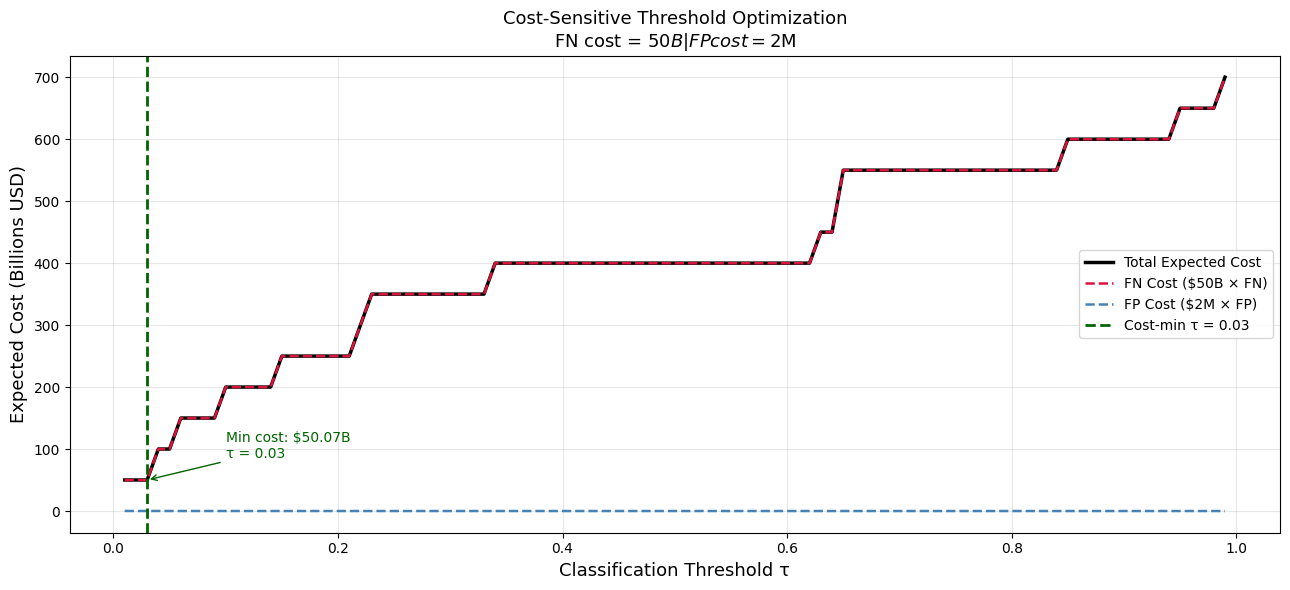

Cost-Sensitive Threshold Analysis
Cost-minimizing threshold τ:  0.03
Minimum total expected cost:  $50.07B
  False Negatives at τ:       1
  False Positives at τ:       35

Expected cost at τ = 0.50:    $400.02B
  False Negatives at 0.50:    8
  False Positives at 0.50:    9

Cost saving vs. default τ:    $349.95B


In [17]:
# ── AI-Generated Code: Cost-Sensitive Threshold Optimization ──────────────────
COST_FN = 50_000_000_000  # $50 billion per missed crisis
COST_FP =      2_000_000  # $2 million per false alarm
B = 1e9  # scaling factor: costs in billions

tau_sweep = np.arange(0.01, 1.00, 0.01)
cost_records = []

for tau in tau_sweep:
    preds = (logit_probs_test >= tau).astype(int)
    cm_tau = confusion_matrix(y_test_bin, preds)
    tn_, fp_, fn_, tp_ = cm_tau.ravel() if cm_tau.shape == (2, 2) else (
        cm_tau[0, 0], 0, 0, 0
    ) if cm_tau.shape == (1, 1) and y_test_bin.sum() == 0 else (
        0, 0, cm_tau[0, 0], 0
    )
    cost_fn_total = fn_ * COST_FN
    cost_fp_total = fp_ * COST_FP
    total_cost    = cost_fn_total + cost_fp_total
    cost_records.append({
        'tau':       tau,
        'FN':        fn_,
        'FP':        fp_,
        'cost_fn_B': cost_fn_total / B,
        'cost_fp_B': cost_fp_total / B,
        'total_B':   total_cost / B,
    })

cost_df = pd.DataFrame(cost_records)

# Cost-minimizing threshold (highest τ among ties)
min_cost = cost_df['total_B'].min()
cost_min_row = cost_df[cost_df['total_B'] == min_cost].sort_values('tau', ascending=False).iloc[0]

# Cost at default τ = 0.5
cost_at_05 = cost_df.loc[(cost_df['tau'] - 0.50).abs().idxmin()]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(cost_df['tau'], cost_df['total_B'],   color='black',     lw=2.5, label='Total Expected Cost')
ax.plot(cost_df['tau'], cost_df['cost_fn_B'], color='crimson',   lw=1.8, linestyle='--', label='FN Cost ($50B × FN)')
ax.plot(cost_df['tau'], cost_df['cost_fp_B'], color='steelblue', lw=1.8, linestyle='--', label='FP Cost ($2M × FP)')

ax.axvline(cost_min_row['tau'], color='darkgreen', linestyle='--', linewidth=2.0,
           label=f'Cost-min τ = {cost_min_row["tau"]:.2f}')
ax.annotate(
    f'Min cost: ${min_cost:.2f}B\nτ = {cost_min_row["tau"]:.2f}',
    xy=(cost_min_row['tau'], min_cost),
    xytext=(cost_min_row['tau'] + 0.07, min_cost + cost_df['total_B'].max() * 0.05),
    arrowprops=dict(arrowstyle='->', color='darkgreen'),
    fontsize=10, color='darkgreen'
)

ax.set_xlabel('Classification Threshold τ', fontsize=13)
ax.set_ylabel('Expected Cost (Billions USD)', fontsize=13)
ax.set_title('Cost-Sensitive Threshold Optimization\n'
             f'FN cost = $50B | FP cost = $2M', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Cost-Sensitive Threshold Analysis")
print("=" * 55)
print(f"Cost-minimizing threshold τ:  {cost_min_row['tau']:.2f}")
print(f"Minimum total expected cost:  ${min_cost:.2f}B")
print(f"  False Negatives at τ:       {int(cost_min_row['FN'])}")
print(f"  False Positives at τ:       {int(cost_min_row['FP'])}")
print(f"\nExpected cost at τ = 0.50:    ${cost_at_05['total_B']:.2f}B")
print(f"  False Negatives at 0.50:    {int(cost_at_05['FN'])}")
print(f"  False Positives at 0.50:    {int(cost_at_05['FP'])}")
print(f"\nCost saving vs. default τ:    ${cost_at_05['total_B'] - min_cost:.2f}B")


The cost-minimizing threshold of 0.03 is much lower than both the F1-optimal threshold (0.13) and the capacity-constrained threshold (0.88). They differ because each threshold optimizes a different goal: total economic cost, balanced classification score, or limited IMF mission capacity. I would recommend the 0.03 threshold because the cost of missing crises is far greater than the cost of false alarms.